# P.Raghu

# 25MML0029

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

# Load pretrained MobileNetV2
model = MobileNetV2(weights='imagenet')

import cv2
import numpy as np

def extract_frames(video_path, max_frames=20):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Cannot open video")
        return np.array([])

    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Handle videos where frame count is 0
    if total_frames > 0:
        step = max(1, total_frames // max_frames)
    else:
        step = 1

    count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if count % step == 0:
            frame = cv2.resize(frame, (224, 224))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # 🔴 Important fix
            frames.append(frame)

        count += 1

        if len(frames) >= max_frames:
            break

    cap.release()
    print("Extracted frames:", len(frames))
    return np.array(frames)



def classify_video(video_path):
    frames = extract_frames(video_path)

    if len(frames) == 0:
        print("No frames extracted!")
        return

    frames = preprocess_input(frames)
    predictions = model.predict(frames)

    # Average predictions across frames
    avg_pred = np.mean(predictions, axis=0)
    #top_pred = decode_predictions(np.expand_dims(avg_pred, axis=0), top=1)

    top_pred = decode_predictions(np.expand_dims(avg_pred, axis=0), top=5)

    for pred in top_pred[0]:
      print(pred[1], ":", round(pred[2]*100, 2), "%")


    print("Final Prediction:", top_pred[0][0][1])

# Replace with your video path
video_path = "real_world_demo_video.mp4"
classify_video(video_path)

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Extracted frames: 20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
digital_clock : 63.84 %
traffic_light : 9.13 %
switch : 1.43 %
computer_keyboard : 1.32 %
matchstick : 0.85 %
Final Prediction: digital_clock


## Here Mobile net is detecting digital clock,traffic light, switch,computer_keyboard,matchstick which is not presented in that list, so its giving the wrong predictions

1. **Trained Only on ImageNet Classes**
   MobileNetV2 is trained on the ImageNet dataset, which contains only 1000 predefined object categories. If an object in the video does not belong to these categories, the model is forced to choose the closest matching class, even if it is incorrect.

2. **No Unknown or Background Class**
   The softmax output layer of MobileNetV2 always produces a probability distribution across all known classes. Since there is no “unknown” or “none of the above” class, the model must output a label even when the object is unfamiliar.

3. **Frame-Based Classification Without Context**
   The model classifies each video frame independently as a static image. Important contextual information and relationships between frames are ignored, leading to misclassification of partial or unclear objects.

4. **Averaging Predictions Amplifies Errors**
   Averaging predictions across frames can strengthen incorrect predictions if similar false patterns appear repeatedly due to motion blur, lighting changes, or background textures.

5. **Domain Mismatch Between Training and Real-World Videos**
   ImageNet images are high-quality, well-centered, and contain clear objects, whereas real-world videos have noise, motion blur, and complex backgrounds. This domain shift causes inaccurate predictions.



In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions

# Load pretrained ResNet50
model = ResNet50(weights='imagenet')

def extract_frames(video_path, max_frames=20):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Cannot open video")
        return np.array([])

    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames > 0:
        step = max(1, total_frames // max_frames)
    else:
        step = 1

    count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if count % step == 0:
            frame = cv2.resize(frame, (224, 224))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # Convert BGR → RGB
            frames.append(frame)

        count += 1

        if len(frames) >= max_frames:
            break

    cap.release()
    print("Extracted frames:", len(frames))
    return np.array(frames)


def classify_video(video_path):
    frames = extract_frames(video_path)

    if len(frames) == 0:
        print("No frames extracted!")
        return

    # Preprocess for ResNet
    frames = preprocess_input(frames)

    predictions = model.predict(frames)

    # Average predictions across frames
    avg_pred = np.mean(predictions, axis=0)

    top_pred = decode_predictions(
        np.expand_dims(avg_pred, axis=0),
        top=5
    )

    print("\nTop 5 Predictions:")
    for pred in top_pred[0]:
        print(pred[1], ":", round(pred[2] * 100, 2), "%")

    print("\nFinal Prediction:", top_pred[0][0][1])


# Replace with your video path
video_path = "real_world_demo_video.mp4"
classify_video(video_path)


102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Extracted frames: 20
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step

Top 5 Predictions:
envelope : 15.12 %
web_site : 11.96 %
tripod : 10.28 %
digital_clock : 5.22 %
crane : 4.17 %

Final Prediction: envelope


#  Print the shape of the frames

In [ ]:
extracted_frames = extract_frames(video_path)
print("Shape of frames:", extracted_frames.shape)
print(extracted_frames[0])

Extracted frames: 20
Shape of frames: (20, 224, 224, 3)
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


# Printing Each frame

Displaying frame 1/20


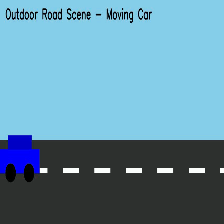

Displaying frame 2/20


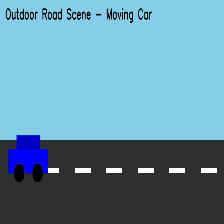

Displaying frame 3/20


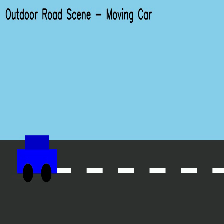

Displaying frame 4/20


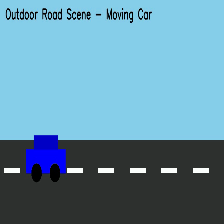

Displaying frame 5/20


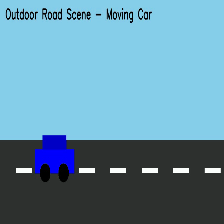

Displaying frame 6/20


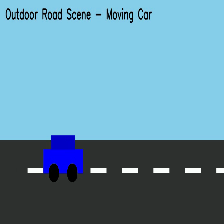

Displaying frame 7/20


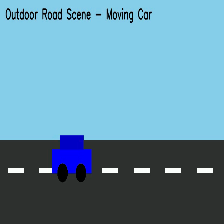

Displaying frame 8/20


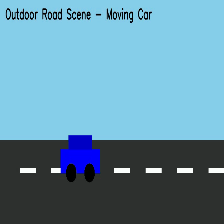

Displaying frame 9/20


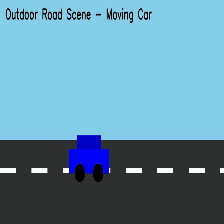

Displaying frame 10/20


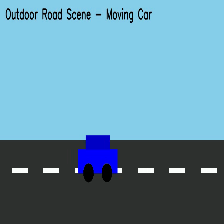

Displaying frame 11/20


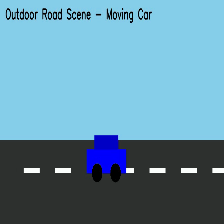

Displaying frame 12/20


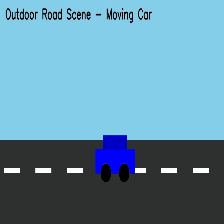

Displaying frame 13/20


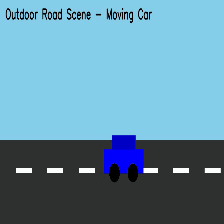

Displaying frame 14/20


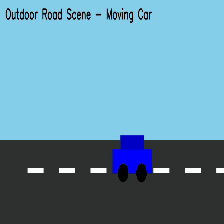

Displaying frame 15/20


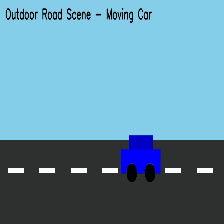

Displaying frame 16/20


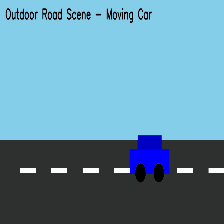

Displaying frame 17/20


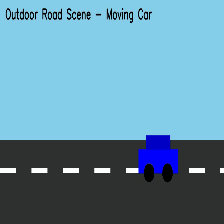

Displaying frame 18/20


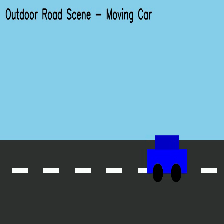

Displaying frame 19/20


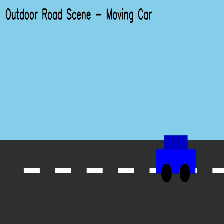

Displaying frame 20/20


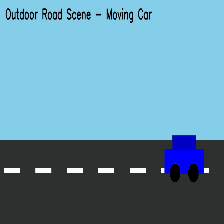

In [ ]:
from google.colab.patches import cv2_imshow

for i, frame in enumerate(extracted_frames):
    print(f"Displaying frame {i+1}/{len(extracted_frames)}")
    cv2_imshow(frame)

## Now iam using A CNN + LSTM hybrid model is used for video classification

In [2]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, LSTM, Dense, Dropout


# PARAMETERS
IMG_SIZE = 224
MAX_FRAMES = 20

NUM_CLASSES = 2
CLASS_NAMES = ["no_car", "car"]   # ✅ CHANGED HERE


# FRAME EXTRACTION
def extract_frames(video_path, max_frames=MAX_FRAMES):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Cannot open video")
        return None

    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, total_frames // max_frames)

    count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if count % step == 0:
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

        count += 1
        if len(frames) >= max_frames:
            break

    cap.release()

    if len(frames) == 0:
        return None

    # Padding if frames < max_frames
    while len(frames) < max_frames:
        frames.append(frames[-1])

    return np.array(frames)

# MODEL BUILDING
cnn = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

cnn.trainable = False

model = Sequential([
    TimeDistributed(cnn, input_shape=(MAX_FRAMES, IMG_SIZE, IMG_SIZE, 3)),
    LSTM(128),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# VIDEO PREPARATION
def prepare_video(video_path):
    frames = extract_frames(video_path)
    if frames is None:
        return None

    frames = preprocess_input(frames)
    return np.expand_dims(frames, axis=0)

# PREDICTION
video_path = "real_world_demo_video.mp4"  # your video

X = prepare_video(video_path)

if X is not None:
    preds = model.predict(X)
    class_id = np.argmax(preds)
    confidence = np.max(preds) * 100

    print("Predicted Class:", CLASS_NAMES[class_id])
    print("Confidence:", round(confidence, 2), "%")
else:
    print("Video processing failed.")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_1              │ (None, 20, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,987,778 (11.40 MB)

 Trainable params: 729,794 (2.78 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 25s 25s/step
Predicted Class: no_car
Confidence: 73.43 %


## Why the CNN + LSTM Model Works

MobileNetV2 (CNN) is used as a feature extractor for individual video frames.

A TimeDistributed layer applies the same CNN to every frame in the video.

LSTM (Long Short-Term Memory) is used to learn temporal relationships between frames.

The final Dense layer classifies the video into car or no_car.

MobileNetV2 captures important spatial features such as car shape, edges, and structure.

Transfer learning allows the model to reuse pretrained knowledge, reducing training time.

LSTM learns motion and continuity, which helps identify a car appearing across frames.

Temporal learning reduces false predictions caused by blur or background noise.

The model predicts only task-specific classes (car / no_car) instead of forcing ImageNet labels.